# Variáveis aleatórias multidimensionais

Este notebook apresenta os conceitos fundamentais de **esperança e variância em variáveis aleatórias multidimensionais**, com foco em interpretação e aplicações em Data Science.

## **Esperança e Variância Condicionais**

#### Esperança de um Vetor Aleatório

A esperança de uma função $g(X, Y)$ generaliza o conceito de média para múltiplas variáveis:

##### Caso Discreto

$$
\mathbb{E}[g(X,Y)] = \sum_i \sum_j g(x_i, y_j) P(X = x_i, Y = y_j)
$$

##### Caso Contínuo

$$
\mathbb{E}[g(X,Y)] = \int_{-\infty}^{\infty} \int_{-\infty}^{\infty} g(x,y) f(x,y)\,dx\,dy
$$

##### Intuição

- É a média ponderada considerando **todas as combinações possíveis de X e Y**
- Base para cálculo de momentos, covariância e modelos probabilísticos

---

#### 2. Independência (Propriedades Importantes)

Se $X$ e $Y$ são independentes:

##### Esperança do Produto

$$
\mathbb{E}[XY] = \mathbb{E}[X]\mathbb{E}[Y]
$$

##### Variância da Soma

$$
\mathrm{Var}(X + Y) = \mathrm{Var}(X) + \mathrm{Var}(Y)
$$

##### Interpretação

- Independência simplifica muito os cálculos
- No mundo real, variáveis raramente são totalmente independentes

---

#### 3. Esperança Condicional

A esperança condicional representa o valor médio de uma variável dado o conhecimento de outra:

$$
\mathbb{E}[X \mid Y]
$$

##### Caso Contínuo

$$
\mathbb{E}[X \mid Y = y] = \int x f_{X \mid Y}(x \mid y)\,dx
$$

##### Intuição

- "Qual o valor esperado de X sabendo Y?"
- É uma **função de Y**, não um valor fixo

---

#### 4. Variância Condicional

A variância condicional mede a dispersão de X após conhecermos Y:

$$
\mathrm{Var}(X \mid Y) = \mathbb{E}[X^2 \mid Y] - (\mathbb{E}[X \mid Y])^2
$$

##### Intuição

- Mede a **incerteza restante** após observar Y
- Quanto menor → mais previsível é X dado Y

---

#### 5. Lei da Esperança Total

Um dos resultados mais importantes:

$$
\mathbb{E}[X] = \mathbb{E}[\mathbb{E}[X \mid Y]]
$$

#### Caso Discreto

$$
\mathbb{E}[X] = \sum_y \mathbb{E}[X \mid Y = y] P(Y = y)
$$

#### Intuição

- A média global é a média das médias condicionais
- Permite decompor problemas complexos em partes menores

---

#### 6. Conexão com Covariância

A covariância pode ser escrita usando esperança:

$$
\mathrm{Cov}(X,Y) = \mathbb{E}[XY] - \mathbb{E}[X]\mathbb{E}[Y]
$$

Isso conecta diretamente com:
- dependência entre variáveis
- estrutura dos dados

---

#### 7. Conexão com Machine Learning

##### Regressão

O objetivo de modelos supervisionados é estimar:

$$
\mathbb{E}[Y \mid X]
$$

Ou seja:

> prever o valor médio de Y dado X

---

#### Incerteza do Modelo

A variância condicional:

$$
\mathrm{Var}(Y \mid X)
$$

indica:
- regiões com maior erro
- dificuldade de previsão

---

##### *Exemplos práticos*

- Prever gasto dado renda → $\mathbb{E}[Y \mid X]$  
- Avaliar risco → $\mathrm{Var}(Y \mid X)$  
- Sistemas de recomendação → expectativa de nota dada interação  

---

- Esperança → valor médio  
- Esperança condicional → previsão  
- Variância condicional → incerteza  
- Lei da esperança total → decomposição  

##### *Exercício 1: O Trabalhador na Mina (Lei da Esperança Total)*

Cenário

Um trabalhador está preso em uma mina com 3 portas, cada uma com probabilidade igual:

- Porta 1 → saída em 2 horas  
- Porta 2 → leva 3 horas e retorna ao início  
- Porta 3 → leva 5 horas e retorna ao início  

 Objetivo

Calcular o **tempo esperado total até sair da mina**.

 Solução

Seja $E$ o tempo esperado total.

Aplicando a **Lei da Esperança Total**:

$$
E = \frac{1}{3}(2) + \frac{1}{3}(3 + E) + \frac{1}{3}(5 + E)
$$

 Resolvendo

$$
E = \frac{2}{3} + \frac{3 + E}{3} + \frac{5 + E}{3}
$$

Multiplicando tudo por 3:

$$
3E = 2 + (3 + E) + (5 + E)
$$

$$
3E = 2 + 3 + E + 5 + E
$$

$$
3E = 10 + 2E
$$

$$
E = 10
$$

 Resultado

O tempo esperado para sair da mina é:

$$
E = 10 \text{ horas}
$$

 Intuição

- Mesmo com caminhos curtos, os retornos aumentam o tempo total  
- A recursividade (voltar ao início) é o que gera a equação  

---

In [3]:
import numpy as np
import random as random

passagens = ['A', 'B', 'C']

ET = []
for i in range(0, 100):
    T = 0
    escolha = random.choice(passagens)
    if (escolha == 'A'):
        T = T + 2
    else:
        while (escolha != 'A'):
            # print('Passagem escolhida: ' + escolha)
            if (escolha == 'B'):
                T = T + 3
            else:
                if (escolha == 'C'):
                    T = T + 5
            escolha = random.choice(passagens)
        T = T + 2
    ET.append(T) 
print('Tempo médio:', np.mean(ET))   

Tempo médio: 10.67


##### *Exercício 2: Desempenho do Jogador (Distribuição Misturada)* 
Um jogador de futebol irá participar de uma partida e sua posição depende da estratégia definida pelo treinador. Se ele jogar no ataque, a probabilidade de fazer gols tem distribuição de Poisson com taxa igual a 2 gols por jogo. Se atuar no meio de campo, a taxa é de um gol por jogo.  Assuma que a probabilidade do jogador atuar no ataque é igual a 2/3 e no meio de campo, 1/3.  Qual é o número esperado de gols que o jogador fará durante a temporada?


Cenário

Um jogador pode atuar em duas posições:

- Ataque → $P = \frac{2}{3}$, média $\lambda = 2$ gols  
- Meio-campo → $P = \frac{1}{3}$, média $\lambda = 1$ gol  

Objetivo

Calcular o **número médio de gols por jogo**.

Solução

Sabemos que, para a distribuição de Poisson:

$$
\mathbb{E}[X] = \lambda
$$

Aplicando a **Lei da Esperança Total**:

$$
\mathbb{E}[X] = \mathbb{E}[X \mid \text{Meio}] P(\text{Meio}) + \mathbb{E}[X \mid \text{Ataque}] P(\text{Ataque})
$$

Cálculo

$$
\mathbb{E}[X] = 1 \cdot \frac{1}{3} + 2 \cdot \frac{2}{3}
$$

$$
\mathbb{E}[X] = \frac{1}{3} + \frac{4}{3}
$$

$$
\mathbb{E}[X] = \frac{5}{3} \approx 1{,}67
$$

Resultado

O número médio de gols por jogo é:

$$
\mathbb{E}[X] \approx 1{,}67
$$

Intuição

- O jogador tem dois “regimes” de desempenho  
- O resultado final é uma média ponderada entre eles  
- Esse tipo de problema é chamado de **distribuição misturada**

**Simulação: Distribuição Misturada (Desempenho do Jogador)**

- Ataque → maior média de gols  
- Meio-campo → menor média  

A posição é escolhida aleatoriamente a cada jogo.

In [ ]:
import numpy as np
np.random.seed(10)
p = 2/3 # probabilidade de jogar no ataque
lbd1 = 1 # taxa de gols no meio do campo
lbd2 = 2 # taxa de gols no ataque
ns = 1000 # número de simulações
goals = 0 # número de gols
for s in range(0,ns):
    if (np.random.uniform() < p):
        # jogador joga no ataque
        goals = goals + np.random.poisson(lbd2)
    else:
        # jogador joga no meio do campo
        goals = goals + np.random.poisson(lbd1)
print("E[X] = ", goals/ns)

E[X] =  1.632


## **Covariância e Correlação**

Esta seção apresenta os conceitos de **dependência linear entre variáveis**, fundamentais para análise de dados e Machine Learning.

---

#### 1. Covariância

A covariância mede como duas variáveis variam juntas:

$$
\mathrm{Cov}(X,Y) = \mathbb{E}[(X - \mathbb{E}[X])(Y - \mathbb{E}[Y])]
$$

Forma equivalente:

$$
\mathrm{Cov}(X,Y) = \mathbb{E}[XY] - \mathbb{E}[X]\mathbb{E}[Y]
$$

##### Interpretação

- Cov > 0 → variáveis crescem juntas  
- Cov < 0 → uma cresce enquanto a outra diminui  
- Cov = 0 → sem relação linear  

##### Caso especial

$$
\mathrm{Cov}(X,X) = \mathrm{Var}(X)
$$

---

#### 2. Correlação de Pearson

A correlação é a covariância normalizada:

$$
\rho_{X,Y} = \frac{\mathrm{Cov}(X,Y)}{\sigma_X \sigma_Y}
$$

##### Propriedades

- Sempre entre -1 e 1  
- $\rho = 1$ → correlação positiva perfeita  
- $\rho = -1$ → correlação negativa perfeita  
- $\rho = 0$ → ausência de relação linear  

##### Observação importante

Correlação zero **não implica independência**  
→ pode existir relação não linear

---

#### 3. Matriz de Covariância

Em problemas multidimensionais, usamos a matriz:

$$
\Sigma =
\begin{pmatrix}
\sigma_1^2 & \sigma_{12} \\
\sigma_{12} & \sigma_2^2
\end{pmatrix}
$$

##### Interpretação

- Diagonal → variâncias  
- Fora da diagonal → covariâncias  

Essa matriz descreve completamente a **dependência linear entre variáveis**

---

#### 4. Distribuição Normal Multivariada

Generalização da normal para múltiplas variáveis:

$$
\mathbf{X} \sim \mathcal{N}(\mu, \Sigma)
$$

##### Intuição

- $\mu$ → centro dos dados  
- $\Sigma$ → forma e inclinação  

A matriz de covariância define:
- direção da nuvem de pontos  
- nível de dispersão  
- correlação entre variáveis  

---

#### 5. Visualização e Intuição

##### Relação forte

- $|\rho| \approx 1$ → pontos alinhados  
- padrão linear claro  

##### Relação fraca

- $|\rho|$ pequeno → pontos dispersos  

##### Limitação do Pearson

- não detecta relações não lineares  
- ex: padrões em U, círculo, etc.

---

#### 6. Estimador Amostral

Na prática, usamos dados amostrais:

$$
r =
\frac{
\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})
}{
\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2}
\sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2}
}
$$

---

#### 7. Conexão com Machine Learning

**Feature Selection**

- variáveis muito correlacionadas → redundância  
- causa multicolinearidade  


**PCA (Principal Component Analysis)**

- usa a matriz de covariância  
- encontra direções de maior variância  


**Modelagem**

- regressão depende da relação entre variáveis  
- correlação ajuda a identificar padrões  


**Análise de Risco**

- covariância usada para diversificação  
- baixa correlação → menor risco conjunto  


**EDA (Exploração de Dados)**

- scatter plots + correlação → primeira análise  
- ajuda a entender estrutura dos dados  

**Insights**

- Covariância → direção da relação  
- Correlação → força da relação  
- Matriz de covariância → estrutura dos dados  

Esses conceitos são fundamentais para:
- análise exploratória  
- modelagem estatística  
- machine learning  

---

## Correlação

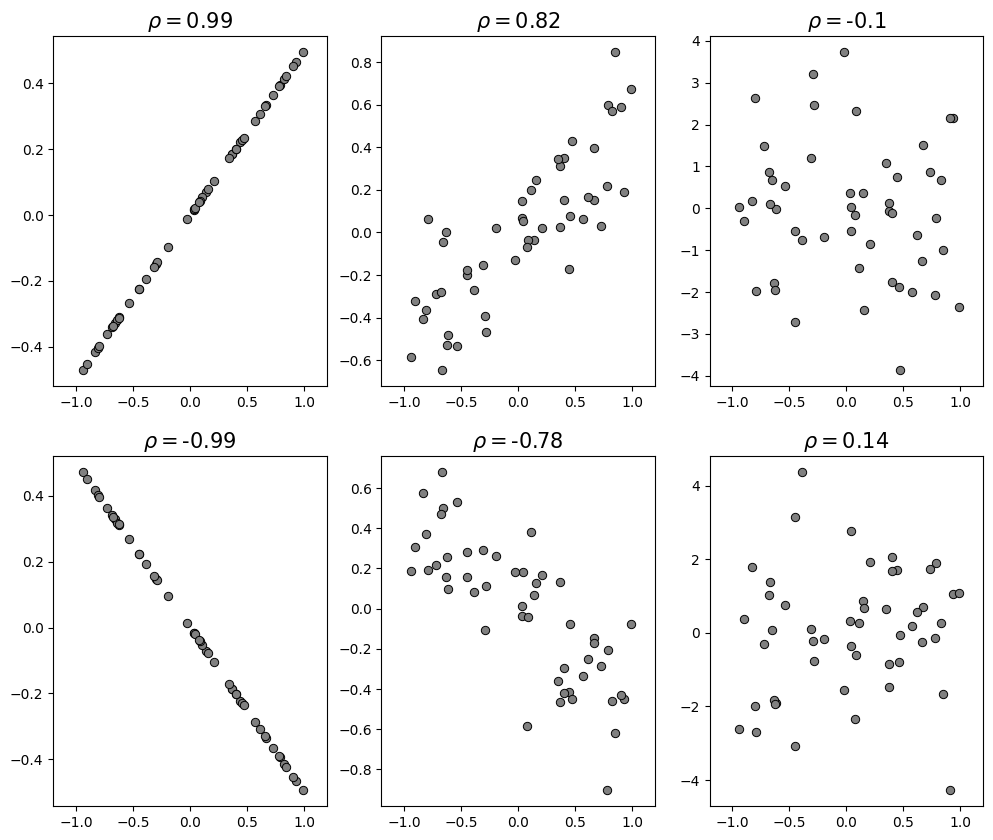

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr


np.random.seed(101)
N = 50 # número de amostras
X = np.random.uniform(-1,1,N)
# valores das variâncias
sigma = [0,0.2,1.5,0,0.2,1.5]
# coeficente de inclinação
a = [0.5,0.5,0.5,-0.5,-0.5,-0.5]
plt.figure(figsize=(12,10))
for i in range(0,len(a)):
    # gera os dados
    Y = a[i]*X + np.random.normal(0,sigma[i],N)
    # mostra os gráficos
    plt.subplot(2,3,i+1)
    plt.plot(X,Y, color = 'gray',
             marker='o', linestyle='None',
             markeredgewidth = 0.7,
             markeredgecolor = 'black')
    plt.xlim(-1.2,1.2)
    # calcula o coeficiente de correlação de Pearson
    corr, p_value = pearsonr(X, Y)
    # mostra apenas duas casas decimais
    corr = int(corr*100)/100
    plt.title(r'$\rho=$'+ str(corr), fontsize=15)
plt.savefig('corr.svg')
plt.show(True)

Comparação entre os coeficientes de Pearson e Spearman.

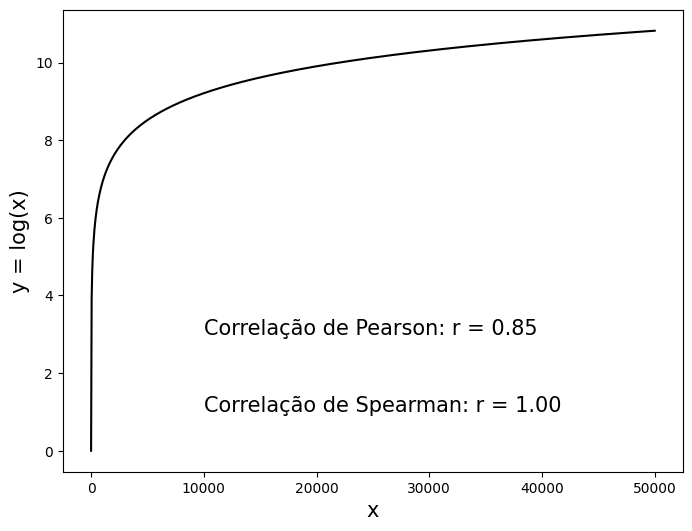

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

N = 1000 # tamanho da amostra
x = np.linspace(1, 50000, N)
y = np.log(x)
# mostra os dados
plt.figure(figsize=(8,6))
plt.plot(x, y, 'k-')
plt.xlabel("x", fontsize = 15)
plt.ylabel("y = log(x)", fontsize = 15)
corr, p_value = pearsonr(x, y) # correlação de Pearson
corrs, p_values = spearmanr(x, y) # correlação de Spearman
st = 'Correlação de Pearson: '+ "r = {:.2f}".format(corr)
plt.text(10000,3, st, fontsize=15)
st = 'Correlação de Spearman: '+ "r = {:.2f}".format(corrs)
plt.text(10000,1, st, fontsize=15)
plt.show()

Correlação nos dados da flor iris.

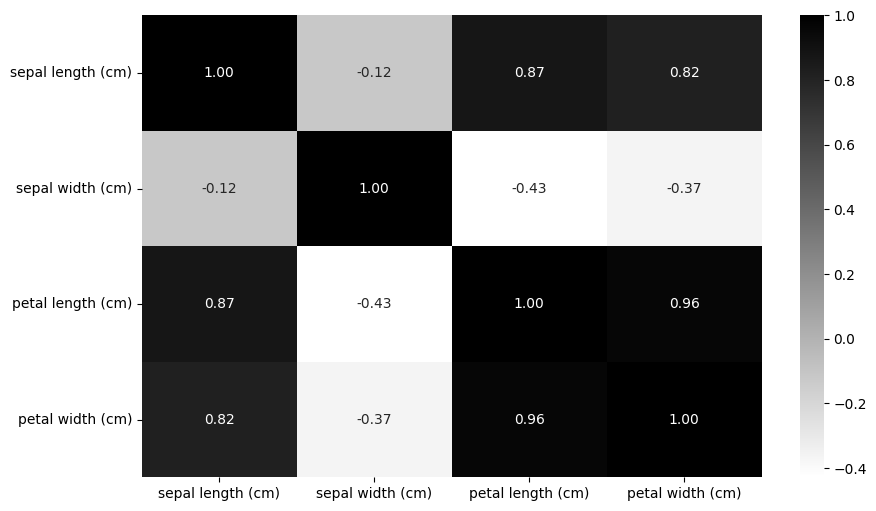

In [ ]:
import pandas as pd
from sklearn import datasets
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
# carrega os dados
iris = datasets.load_iris()
# transforma em um dataframe do Pandas
df = pd.DataFrame(data=iris.data,
                  columns=iris.feature_names)
# mostra as correlações
hm = sns.heatmap(df.corr(), annot = True,
                 cmap='gist_gray_r', fmt='.2f')
plt.savefig('corr2.svg')
plt.show()

A correlação de Spearman entre o comprimento e a largura da pétala da flor iris.

In [ ]:
import pandas as pd
from sklearn import datasets
from scipy.stats import spearmanr, pearsonr

# carrega os dados
iris = datasets.load_iris()
# transforma em um dataframe do Pandas
df = pd.DataFrame(data=iris.data,
                  columns=iris.feature_names)
# comprimento da pétala ('petal length')
X = df[iris.feature_names[2]]
# largura da pétala ('petal width')
Y = df[iris.feature_names[3]]
corrp, p_value_p = pearsonr(X, Y) # correlação de Pearson
print('Correlação de Pearson:', corrp)
corrs, p_value_s = spearmanr(X, Y) # correlação de Spearman
print('Correlação de Spearman:', corrs)

Correlação de Pearson: 0.962865431402796
Correlação de Spearman: 0.9376668235763412
